In [ ]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Installing openpyxl for reading Excel files
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Loading/reading the Excel dataset
df = pd.read_excel("Monthly_traffic_data_1992-current.xlsx")

In [14]:
# Filtering the Excel dataset
df = pd.read_excel(
    "Monthly_traffic_data_1992-current.xlsx",
    header=[7, 8]
)

data = df[
    [
        ('Unnamed: 0_level_0', 'Year'),
        ('Unnamed: 1_level_0', 'Month'),
        ('Passengers', 'Total*')
    ]
].copy()

data.columns = ['Year', 'Month', 'Passengers']
data['Year'] = data['Year'].ffill()

months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

data = data[data['Month'].isin(months)].copy()

data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
data = data.dropna(subset=['Year'])
data['Year'] = data['Year'].astype(int)

data['Date'] = pd.to_datetime(
    data['Year'].astype(str) + ' ' + data['Month'],
    format='%Y %B'
)

data.head(15)

,Year,Month,Passengers,Date
0,1992,January,1149822.0,1992-01-01
1,1992,February,1086979.0,1992-02-01
2,1992,March,1276674.0,1992-03-01
3,1992,April,1522522.0,1992-04-01
4,1992,May,1742117.0,1992-05-01
5,1992,June,1737275.0,1992-06-01
6,1992,July,1979900.0,1992-07-01
7,1992,August,2061036.0,1992-08-01
8,1992,September,1867943.0,1992-09-01
9,1992,October,1707752.0,1992-10-01


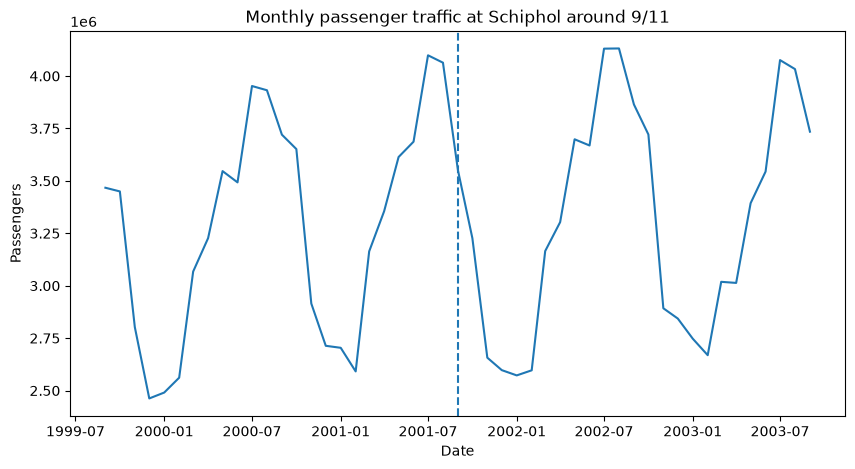

In [ ]:
# Monthly passenger graph 9/11
event_911 = data[
    (data['Date'] >= '1999-09-01') &
    (data['Date'] <= '2003-09-01')
].copy()

plt.figure(figsize=(10, 5))

plt.plot(event_911['Date'], event_911['Passengers'])

plt.axvline(
    pd.Timestamp('2001-09-01'),
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Passengers')
plt.title('Monthly passenger traffic at Schiphol around 9/11')

plt.show()

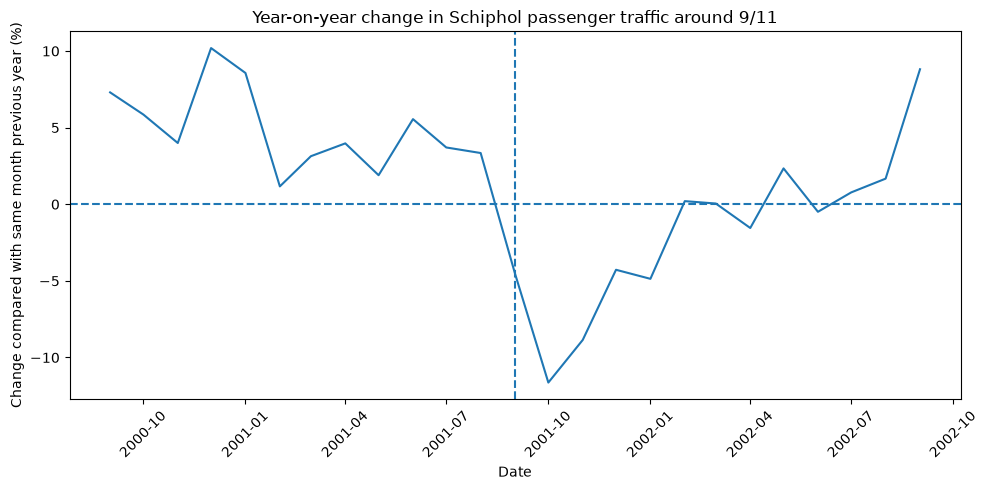

In [ ]:
# Comparative graph for 9/11
comparison_911 = event_911[
    (event_911['Date'] >= '2000-09-01') &
    (event_911['Date'] <= '2002-09-01')
].copy()

plt.figure(figsize=(10, 5))

plt.plot(
    comparison_911['Date'],
    comparison_911['Year_on_year_change']
)

plt.axhline(0, linestyle='--')

plt.axvline(
    pd.Timestamp('2001-09-01'),
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Change compared with same month previous year (%)')
plt.title('Year-on-year change in Schiphol passenger traffic around 9/11')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

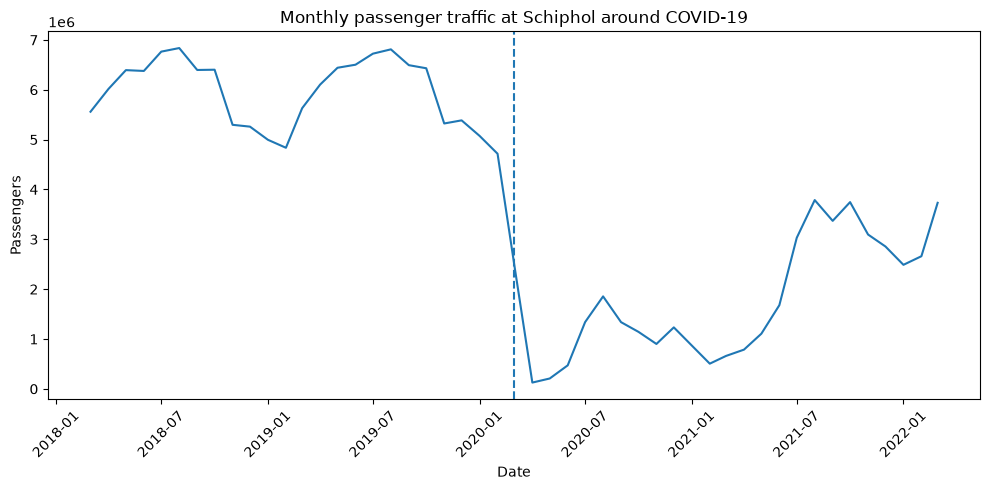

In [15]:
# Monthly passenger graph COVID-19
# We create an event 'COVID-19' with the corresponding time frame
event_covid = data[
    (data['Date'] >= '2018-03-01') &
    (data['Date'] <= '2022-03-01')
].copy()


# We create a plot to visualise the COVID-19 event
plt.figure(figsize=(10, 5))

plt.plot(event_covid['Date'], event_covid['Passengers'])

plt.axvline(
    pd.Timestamp('2020-03-01'),
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Passengers')
plt.title('Monthly passenger traffic at Schiphol around COVID-19')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

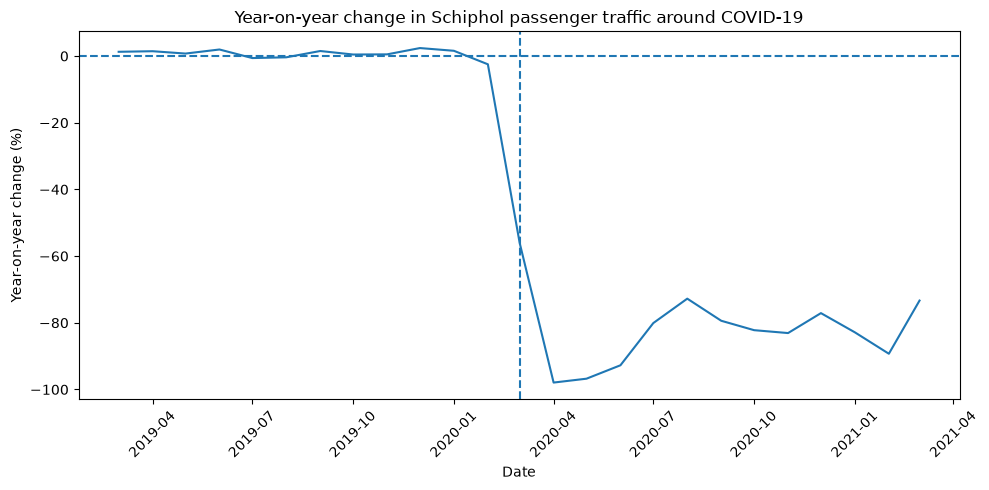

In [17]:
# Comparative graph for COVID-19
event_covid['Passengers_previous_year'] = event_covid['Passengers'].shift(12)

event_covid['Year_on_year_change'] = (
    (event_covid['Passengers'] - event_covid['Passengers_previous_year'])
    / event_covid['Passengers_previous_year']
) * 100

comparison_covid = event_covid[
    (event_covid['Date'] >= '2019-03-01') &
    (event_covid['Date'] <= '2021-03-01')
].copy()

plt.figure(figsize=(10, 5))

plt.plot(
    comparison_covid['Date'],
    comparison_covid['Year_on_year_change'],
)

plt.axhline(0, linestyle='--')

plt.axvline(
    pd.Timestamp('2020-03-01'),
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Year-on-year change (%)')
plt.title('Year-on-year change in Schiphol passenger traffic around COVID-19')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

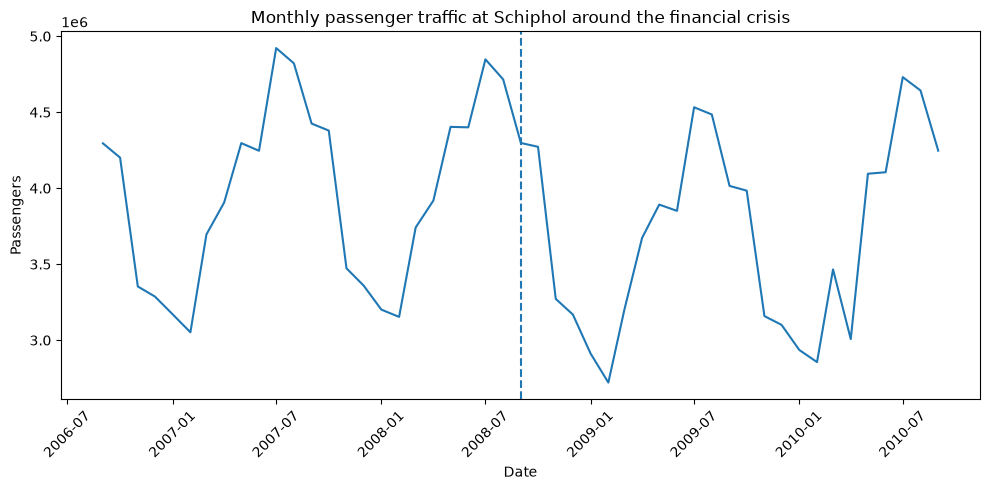

In [18]:
# Monthly passenger graph financial crisis
# We create an event 'financial crisis' with the corresponding time frame
event_financial = data[
    (data['Date'] >= '2006-09-01') &
    (data['Date'] <= '2010-09-01')
].copy()

# We plot the financial crisis event
plt.figure(figsize=(10, 5))

plt.plot(event_financial['Date'], event_financial['Passengers'])

plt.axvline(
    pd.Timestamp('2008-09-01'),
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Passengers')
plt.title('Monthly passenger traffic at Schiphol around the financial crisis')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

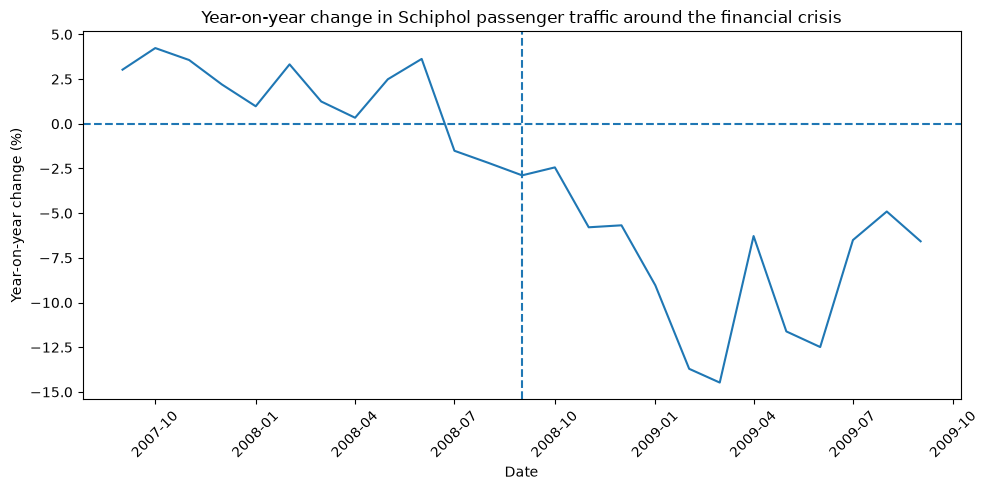

In [22]:
# Comparative graph for financial crisis
event_financial['Passengers_previous_year'] = event_financial['Passengers'].shift(12)

event_financial['Year_on_year_change'] = (
    (event_financial['Passengers'] - event_financial['Passengers_previous_year'])
    / event_financial['Passengers_previous_year']
) * 100

comparison_financial = event_financial[
    (event_financial['Date'] >= '2007-09-01') &
    (event_financial['Date'] <= '2009-09-01')
].copy()

plt.figure(figsize=(10, 5))

plt.plot(
    comparison_financial['Date'],
    comparison_financial['Year_on_year_change']
)

plt.axhline(0, linestyle='--')

plt.axvline(
    pd.Timestamp('2008-09-01'),
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Year-on-year change (%)')
plt.title('Year-on-year change in Schiphol passenger traffic around the financial crisis')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()